# Du marché au bilan : le pont théorie des jeux ↔ théorie de la décision

> **Navigation** : [GameTheory-17](GameTheory-17-MultiAgent-RL.ipynb) ·
> [GameTheory-17b](GameTheory-17b-Asymmetric-Information.ipynb) (prérequis direct) ·
> ce carnet est la **face assureur** de 17b.

[GameTheory-17b](GameTheory-17b-Asymmetric-Information.ipynb) a établi la **vue
marché** de l'information asymétrique : qui contracte avec qui, à quel prix
d'équilibre — point fixe d'Akerlof, signal de Spence, menu séparateur de
Rothschild–Stiglitz, anticipation de Wilson/Miyazaki. Ce carnet relit **les
mêmes objets depuis l'autre côté du comptoir**, celui de l'assureur qui doit :

1. **tarifer** — décomposer la prime en prime pure et chargement (§1-§2) ;
2. **créditer l'expérience individuelle** — crédibilité de Bühlmann–Straub (§3) ;
3. **immobiliser du capital** — ruine de Cramér–Lundberg quand l'équilibre de
   marché rate (§4) ;
4. **payer pour de l'information** — la valeur d'un questionnaire de
   souscription en équivalent EVSI (§5).

La correspondance est exacte, pas une métaphore : le contrat $(\alpha, \beta)$
de 17b (couverture $\alpha$, prime $\beta$) est l'objet unique lu deux fois —
comme échange d'utilité espérée côté marché, comme flux de primes et de
sinistres côté bilan. Chaque section croise ainsi un modèle de 17b avec une
tranche de la série actuarielle *DecisionTheory* (EPIC #12904, tranches T1
prime, T3 crédibilité, T4 ruine, T5 valeur d'information — carnets DecPyMC
en cours d'intégration, référencés par concept).

**Prérequis** : 17b (contrats, types, menus) ; notions de Poisson et
d'espérance conditionnelle.

In [1]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng(20260825)
plt.rcParams["figure.dpi"] = 110

# Les deux types de risque de la serie Decision Theory (T1) :
# frequence de sinistre annuelle, severite unitaire.
THETA_LOW, THETA_HIGH = 0.01, 0.04
GAMMA = 0.7          # aversion au risque absolue (CARA), comme en 17b
WEALTH = 10.0        # richesse initiale de l'assure
SEVERITY = 1.0       # sinistralite unitaire (indemnite = alpha * severite)

## §1 Le contrat, objet double : utilité espérée contre flux de sinistres

**Côté marché** (17b) : l'assuré de type $\theta$ compare les contrats par
utilité espérée CARA, $u(w) = -e^{-\gamma w}$ ; un menu est un équilibre
séparateur si chaque type préfère *son* contrat (incitation) et préfère
s'assurer plutôt que de s'arrêter (participation).

**Côté assureur** : le même contrat $(\alpha, \beta)$ promet une prime
$\beta$ encaissée sûrement et une indemnité $\alpha$ versée avec probabilité
$\theta$. Le **profit espéré** est $\beta - \theta\alpha$ : la **prime pure**
$\theta\alpha$ est le point d'équilibre actuariel, et la concurrence pure de
Rothschild–Stiglitz pousse précisément chaque contrat séparateur sur cette
ligne — **le séparateur RS est un menu break-even par type**.

In [2]:
@dataclass(frozen=True)
class Contract:
    """Le meme objet qu'en 17b : couverture alpha, prime beta."""
    coverage: float
    premium: float

    def expected_loss(self, theta: float) -> float:
        return theta * self.coverage * SEVERITY

    def expected_profit(self, theta: float) -> float:
        return self.premium - self.expected_loss(theta)


def cara_utility_wealth(final_wealth: np.ndarray | float) -> np.ndarray | float:
    return -np.exp(-GAMMA * np.asarray(final_wealth, dtype=float))


def expected_utility(c: Contract, theta: float) -> float:
    """Utilite esperee CARA d'un assure de type theta qui achete (alpha, beta)."""
    w_no_loss = WEALTH - c.premium
    w_loss = WEALTH - c.premium + c.coverage * SEVERITY
    return float(
        (1 - theta) * cara_utility_wealth(w_no_loss)
        + theta * cara_utility_wealth(w_loss)
    )


OUTSIDE_OPTION_U = {
    th: (1 - th) * cara_utility_wealth(WEALTH)
    + th * cara_utility_wealth(WEALTH - SEVERITY)
    for th in (THETA_LOW, THETA_HIGH)
}

# Menu separateur RS : pleine couverture break-even pour chaque type.
menu_rs = {
    "L (risque faible)": Contract(1.0, THETA_LOW),
    "H (risque fort)": Contract(1.0, THETA_HIGH),
}
rows = []
for label, c in menu_rs.items():
    theta = THETA_LOW if label.startswith("L") else THETA_HIGH
    rows.append({
        "contrat": label,
        "prime β": c.premium,
        "sinistre espéré θα": c.expected_loss(theta),
        "profit espéré": c.expected_profit(theta),
        "EU(assuré)": expected_utility(c, theta),
        "option extérieure": OUTSIDE_OPTION_U[theta],
    })
pd.DataFrame(rows).round(5)

,contrat,prime β,sinistre espéré θα,profit espéré,EU(assuré),option extérieure
0,L (risque faible),0.01,0.01,0.0,-0.00091,-0.00092
1,H (risque fort),0.04,0.04,0.0,-0.00092,-0.00095


### Lecture du résultat

Chaque contrat séparateur est exactement break-even ($\beta = \theta\alpha$,
profit espéré nul) : l'hypothèse de concurrence pure **transfère tout le
surplus à l'assuré**. Un assureur réel ne peut pas vivre à l'équilibre
concurrentiel — il doit ajouter un **chargement** $\eta$ sur la prime pure,
$\beta = (1+\eta)\,\theta\alpha$, et ce chargement est immédiatement
plafonné par la contrainte de participation : trop cher, l'assuré retourne à
son option extérieure et le contrat ne vend plus. C'est la décomposition
**prime pure / chargement** de la tranche T1, rencontrée ici depuis le
mécanisme de marché.

## §2 Le chargement maximal : ce que la participation tolère

Le chargement de sécurité le plus élevé que chaque type accepte est celui qui
ramène son utilité espérée exactement à son option extérieure (ne pas
s'assurer). On le trouve par dichotomie : c'est le prix de réserve **du côté
de la demande**, la borne supérieure de tout tarif réel.

In [3]:
def max_loading(theta: float) -> float:
    """Chargement eta maximal tel que EU(contrat charge) >= option exterieure.

    Pleine couverture (alpha = 1), prime (1 + eta) * theta ; dichotomie sur eta.
    """
    def eu_gap(eta: float) -> float:
        c = Contract(1.0, (1.0 + eta) * theta)
        return expected_utility(c, theta) - OUTSIDE_OPTION_U[theta]

    lo, hi = 0.0, 50.0 / theta  # borne large : au-dela, la prime ruine l'assure
    if eu_gap(hi) > 0:
        return hi
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        if eu_gap(mid) > 0:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


eta_max = {th: max_loading(th) for th in (THETA_LOW, THETA_HIGH)}
rows = [
    {
        "type": "L (θ=0.01)" if th == THETA_LOW else "H (θ=0.04)",
        "θ": th,
        "prime pure θα": th,
        "chargement max η*": eta_max[th],
        "prime max (1+η*)θ": (1 + eta_max[th]) * th,
    }
    for th in (THETA_LOW, THETA_HIGH)
]
pd.DataFrame(rows).round(4)

,type,θ,prime pure θα,chargement max η*,prime max (1+η*)θ
0,L (θ=0.01),0.01,0.01,1.1619,0.0216
1,H (θ=0.04),0.04,0.04,1.1461,0.0858


### Lecture du résultat

Surprise : les chargements maximaux **relatifs** sont presque identiques pour
les deux types (à peine plus d'une fois la prime pure), alors que les primes
maximales **absolues** diffèrent d'un facteur quatre. Avec une aversion CARA
et de petites fréquences, la disposition à payer est à peu près
proportionnelle au risque — ce n'est pas le type qui structure le chargement,
c'est **l'aversion au risque** $\gamma$ (exercice : refaire le tableau avec
$\gamma$ doublé). Le chargement réel d'un assureur doit donc rester sous un
plafond **homogène** ~1,15·θ dans ce marché : peu de marge, et toute la
question devient *avec quelle information* l'assureur peut-il prétendre
connaître le $\theta$ auquel ce plafond s'applique — c'est la crédibilité.

## §3 Crédibilité : le marché vend un prior, l'assureur achète de l'expérience

Le menu séparateur suppose le type **connu** — information parfaite. Le
pooling suppose le type **inconnu et identique pour tous**. L'assureur réel
vit entre les deux : il observe un historique de sinistres. La crédibilité de
Bühlmann–Straub quantifie ce chemin :

$$Z = \frac{n}{n + K}, \qquad K = \frac{\text{EPV}}{\text{VHM}},$$

où $n$ est le nombre d'années observées, EPV la variance intra-individu du
comptage et VHM la variance inter-individus des fréquences moyennes. Pour un
comptage **Poisson** de mélange binomial, EPV admet l'estimateur fermé
$s^2 = m$ (la variance conditionnelle d'une Poisson est sa moyenne) — ne pas
la confondre avec la VHM, erreur classique qui produit un $K$ minuscule et un
$Z \approx 1$, c'est-à-dire du no-pooling déguisé.

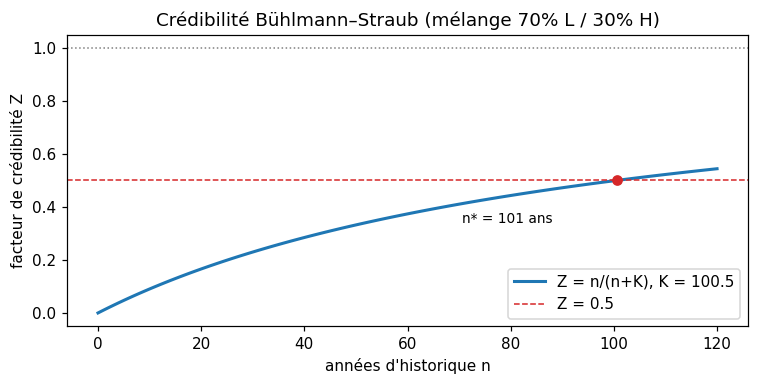

,années observées n,Z,lecture
0,1,0.010,proche du pooling
1,3,0.029,proche du pooling
2,5,0.047,proche du pooling
3,10,0.090,proche du pooling
4,30,0.230,proche du pooling


In [4]:
def buhlmann_straub_constants(pi_high: float, lam_low: float, lam_high: float):
    """EPV, VHM, K pour un melange binomial de deux Poisson.

    EPV (Poisson) : E[Var(N | type)] = E[lambda_type] = m (estimateur ferme).
    VHM : Var(E[N | type]) = pi_H (1 - pi_H) (lam_H - lam_L)^2.
    """
    m = pi_high * lam_high + (1 - pi_high) * lam_low
    vhm = pi_high * (1 - pi_high) * (lam_high - lam_low) ** 2
    epv = m  # Poisson : s^2 = m
    return epv, vhm, epv / vhm


PI_HIGH = 0.30
EPV, VHM, K = buhlmann_straub_constants(PI_HIGH, THETA_LOW, THETA_HIGH)

n_years = np.arange(0, 121)
Z = n_years / (n_years + K)
n_star_half = K * 0.5 / (1 - 0.5)      # Z = 0.5 atteint a n = K
n_star_ninety = K * 0.9 / (1 - 0.9)    # Z = 0.9 atteint a n = 9K

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(n_years, Z, lw=2, label=f"Z = n/(n+K), K = {K:.1f}")
ax.axhline(1.0, color="grey", ls=":", lw=1)
ax.axhline(0.5, color="tab:red", ls="--", lw=1, label="Z = 0.5")
ax.scatter([n_star_half], [0.5], color="tab:red", zorder=3)
ax.annotate(f"n* = {n_star_half:.0f} ans", (n_star_half, 0.5),
            xytext=(n_star_half - 30, 0.34), fontsize=9)
ax.set_xlabel("années d'historique n")
ax.set_ylabel("facteur de crédibilité Z")
ax.set_title(f"Crédibilité Bühlmann–Straub (mélange {1-PI_HIGH:.0%} L / {PI_HIGH:.0%} H)")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

cred_rows = []
for n_obs in (1, 3, 5, 10, 30):
    z = n_obs / (n_obs + K)
    cred_rows.append({
        "années observées n": n_obs,
        "Z": round(z, 3),
        "lecture": (
            "proche du pooling" if z < 0.3
            else "mi-chemin" if z < 0.7
            else "proche du séparateur"
        ),
    })
pd.DataFrame(cred_rows)

### Lecture du résultat

Lire $K$ dans la sortie : de l'ordre de **cent** années, $n^*$ (Z = 0.5) aussi
— après 30 ans d'historique, $Z$ plafonne à 0.23. Le comptage Poisson annuel
est un signal **très bruité** : avec des fréquences de 1% à 4%, la plupart
des années sans sinistre n'apprennent presque rien sur le type. La
crédibilité mesure ici le coût en **temps** de l'information — et ce temps
excède une carrière d'assureur. Le menu séparateur de 17b correspond à $Z = 1$
**immédiat** ; le questionnaire de souscription (§5) achète en une transaction
une grande partie de ce qu'un siècle d'historique ne construirait que
lentement : voilà pourquoi la sélection à l'entrée domine l'*experience
rating* sur ce marché — la lecture assureur du problème d'antisélection.

## §4 Ruine : quand l'équilibre de marché rate, c'est le bilan qui paie

17b montre qu'un équilibre Rothschild–Stiglitz **peut ne pas exister** : selon
la proportion de types H, un contrat déviant détruit le menu. La chaîne
exacte, côté assureur, est l'**écrémage** :

1. **Pooling** : l'assureur propose un contrat unique au prix moyen
   $\bar\theta = \pi_H\theta_H + (1-\pi_H)\theta_L$ — break-even si le
   mélange reste équilibré.
2. **Écrémage** : un déviant propose aux types L un contrat
   $(1,\,\theta_L + \varepsilon)$ strictement meilleur pour eux — le
   pooling ne peut pas suivre sans perdre les H. Les L partent.
3. **Spirale** : le portefeuille restant ne contient plus que des H, mais la
   prime est toujours $\bar\theta < \theta_H$. Chaque contrat devient
   perdant en espérance : le processus de surplus de Cramér–Lundberg

$$U(t) = u + \sum_i \beta_i\, t - S(t)$$

dérive vers la **ruine**. Le menu séparateur, lui, rétablit le break-even par
type. Simulons les deux destins — l'étape 2 étant jouée, le portefeuille A
n'a plus que des H à la prime moyenne ; le portefeuille B reprime chaque type
à sa propre fréquence, plus un chargement de sécurité.

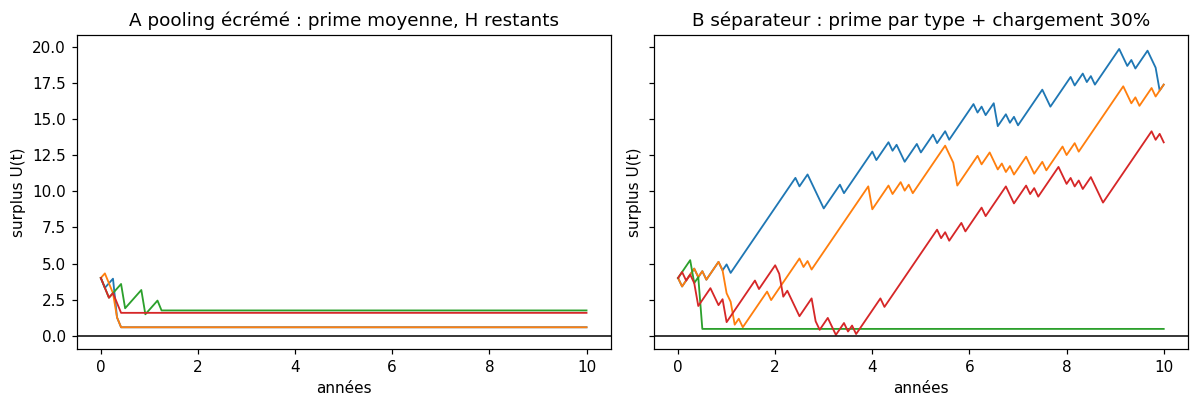

,portefeuille,prime par tête,drift mensuel,fréquence de ruine,surplus final (survivants)
0,A pooling écrémé (étape 3),0.0190,-0.350,1.000,NaN
1,B séparateur + η=30%,0.0247,0.095,0.077,16.76


In [5]:
def simulate_portfolio(
    n_policyholders: int,
    premium_per_head: float,
    claim_rate_per_head: float,
    loading: float,
    horizon_years: float = 10.0,
    n_paths: int = 400,
    initial_capital: float = 4.0,
    seed: int = 17,
) -> dict[str, object]:
    """Surplus Cramer-Lundberg discretise : primes lineaires, sinistres Poisson.

    Renvoie la frequence de ruine (U < 0 a un instant quelconque), le surplus
    final moyen parmi les survivants et quelques trajectoires. Les chemins
    ruines sont geles a leur dernier niveau positif.
    """
    gen = np.random.default_rng(seed)
    dt = 1.0 / 12.0                     # pas mensuel
    steps = int(horizon_years / dt)
    premium_flow = n_policyholders * premium_per_head * (1 + loading) * dt
    lam_step = n_policyholders * claim_rate_per_head * dt
    surplus = np.full(n_paths, initial_capital)
    alive = np.ones(n_paths, dtype=bool)
    history = [surplus.copy()]
    for _ in range(steps):
        claims = gen.poisson(lam_step, size=n_paths) * SEVERITY
        new_surplus = surplus + premium_flow - claims
        alive &= new_surplus >= 0
        surplus = np.where(alive, new_surplus, surplus)  # gele les ruines
        history.append(surplus.copy())
    paths = np.array(history)
    final = paths[-1]
    return {
        "ruin_frequency": float((~alive).mean()),
        "final_surplus_survivors_mean": float(final[alive].mean()) if alive.any() else float("nan"),
        "paths": paths,
    }


# Portefeuille A : pooling ecreme -- prime moyenne, sinistralite H uniquement.
pool_mix_mean = PI_HIGH * THETA_HIGH + (1 - PI_HIGH) * THETA_LOW
portfolio_pooling = simulate_portfolio(
    n_policyholders=200, premium_per_head=pool_mix_mean,
    claim_rate_per_head=THETA_HIGH,   # etape 3 de la spirale : ne restent que des H
    loading=0.0,
)
# Portefeuille B : menu separateur -- chaque type paye sa prime pure + chargement.
n_h, n_l = int(200 * PI_HIGH), int(200 * (1 - PI_HIGH))
sep_mean_rate = (n_h * THETA_HIGH + n_l * THETA_LOW) / 200
portfolio_separating = simulate_portfolio(
    n_policyholders=200,
    premium_per_head=sep_mean_rate,
    claim_rate_per_head=sep_mean_rate,  # break-even par type par construction
    loading=0.30,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
years = np.arange(0, 121) / 12.0
for i in (0, 7, 42, 133):
    axes[0].plot(years, portfolio_pooling["paths"][:, i], lw=1.2)
    axes[1].plot(years, portfolio_separating["paths"][:, i], lw=1.2)
axes[0].axhline(0, color="black", lw=1)
axes[1].axhline(0, color="black", lw=1)
axes[0].set_title("A pooling écrémé : prime moyenne, H restants")
axes[1].set_title("B séparateur : prime par type + chargement 30%")
for ax in axes:
    ax.set_xlabel("années")
    ax.set_ylabel("surplus U(t)")
fig.tight_layout()
plt.show()

pd.DataFrame([
    {
        "portefeuille": "A pooling écrémé (étape 3)",
        "prime par tête": round(pool_mix_mean, 4),
        "drift mensuel": round((pool_mix_mean - THETA_HIGH) * 200 / 12, 3),
        "fréquence de ruine": round(portfolio_pooling["ruin_frequency"], 3),
        "surplus final (survivants)": round(portfolio_pooling["final_surplus_survivors_mean"], 2),
    },
    {
        "portefeuille": "B séparateur + η=30%",
        "prime par tête": round(sep_mean_rate * 1.30, 4),
        "drift mensuel": round(sep_mean_rate * 0.30 * 200 / 12, 3),
        "fréquence de ruine": round(portfolio_separating["ruin_frequency"], 3),
        "surplus final (survivants)": round(portfolio_separating["final_surplus_survivors_mean"], 2),
    },
])

### Lecture du résultat

Le pooling écrémé **se ruine sûrement** : sa prime par tête (0,019) ne couvre
pas la sinistralité de ce qui lui reste (0,04) — le drift mensuel est
négatif, aucune trajectoire ne s'échappe. La spirale d'Akerlof est ici un
**taux de fuite du capital**. Le séparateur survit majoritairement — mais
remarquez que sa fréquence de ruine **ne s'annule pas** : même break-even par
type avec chargement, le risque Poisson résiduel met le surplus sous zéro de
temps en temps. C'est exactement ce que quantifie l'inégalité de Lundberg
(tranche T4) : $\psi(u) \lesssim e^{-\kappa u}$ — la probabilité de ruine
décroît **exponentiellement** avec le capital $u$ et le chargement $\eta$.
La non-existence d'équilibre Rothschild–Stiglitz de 17b a ainsi un prix
comptable : c'est la probabilité de ruine du dernier assureur à avoir cru au
pooling.

## §5 La valeur de l'information : le signal de Spence, lu par l'assureur

En 17b, le signal de Spence est **coûteux pour l'agent** — il sépare les types
parce que son coût est corrélé au type. L'assureur dispose d'un autre canal :
le **questionnaire de souscription** — un test imparfait, gratuit pour
l'agent, payant pour la compagnie.

Cadre : la prime $\beta$ est fixée par le marché au prix moyen
$\bar\theta$ (concurrence, pas de discrimination directe autorisée). Sans
test, l'assureur ne peut rien distinguer : accepter tout le monde rapporte
$\bar\theta - \bar\theta = 0$ en espérance. Avec le test, il décide
**d'accepter ou de refuser chaque segment** : accepter le segment $g$ rapporte
$\bar\theta - \lambda_g$ (son coût espéré posterior) si positif, sinon on
le refuse. La valeur du questionnaire est donc une **valeur d'échantillonnage
d'information** exactement comme en théorie de la décision :

$$\text{EVSI} = \sum_g P(g)\max(\bar\theta - \lambda_g,\, 0), \qquad
\text{EVPI} = \sum_t P(t)\max(\bar\theta - \theta_t,\, 0),$$

où l'EVPI (test parfait) majore toute information possible sur le type.

In [6]:
def test_posteriors(pi_high: float, sens: float, spec: float) -> dict[str, float]:
    """Posterior P(H | resultat) d'un test binaire imparfait.

    sens = P(+ | H), spec = P(- | L).
    """
    p_plus = pi_high * sens + (1 - pi_high) * (1 - spec)
    p_h_given_plus = pi_high * sens / p_plus
    p_h_given_minus = pi_high * (1 - sens) / (1 - p_plus)
    return {"P(+)": p_plus, "P(H|+)": p_h_given_plus, "P(H|-)": p_h_given_minus}


def segment_lambda(pi_h_post: float) -> float:
    """Frequence de sinistre esperee d'un segment de composition pi_h_post."""
    return pi_h_post * THETA_HIGH + (1 - pi_h_post) * THETA_LOW


def underwriting_evsi(pi_high: float, sens: float, spec: float) -> dict[str, float]:
    """EVSI / EVPI d'un questionnaire de souscription a prime fixe theta_bar.

    Sans test : accepter tout le monde = profit nul (prime = cout du melange).
    Avec test : accepter chaque segment ssi son cout posterior < la prime.
    """
    premium = segment_lambda(pi_high)          # prime concurrentielle theta_bar
    post = test_posteriors(pi_high, sens, spec)
    lambda_plus = segment_lambda(post["P(H|+)"])
    lambda_minus = segment_lambda(post["P(H|-)"])
    profit_plus = max(premium - lambda_plus, 0.0)
    profit_minus = max(premium - lambda_minus, 0.0)
    evsi = post["P(+)"] * profit_plus + (1 - post["P(+)"]) * profit_minus
    # EVPI : test parfait, chaque type accepte ssi theta_t < prime.
    evpi = (1 - pi_high) * max(premium - THETA_LOW, 0.0) + pi_high * max(premium - THETA_HIGH, 0.0)
    return {
        "prime β": premium,
        "λ_+": lambda_plus, "λ_-": lambda_minus,
        "décision +": "accepter" if profit_plus > 0 else "refuser",
        "décision -": "accepter" if profit_minus > 0 else "refuser",
        "profit +": profit_plus, "profit -": profit_minus,
        "EVSI": evsi, "EVPI": evpi, "rendement": evsi / evpi if evpi > 0 else float("nan"),
    }


SENS, SPEC = 0.70, 0.80
res = underwriting_evsi(PI_HIGH, SENS, SPEC)
pd.DataFrame([
    {"quantité": "prime concurrentielle β = θ̄", "valeur": round(res["prime β"], 5)},
    {"quantité": "coût espéré du segment + (λ₊)", "valeur": round(res["λ_+"], 5)},
    {"quantité": "coût espéré du segment − (λ₋)", "valeur": round(res["λ_-"], 5)},
    {"quantité": "profit sans test (accepter tout)", "valeur": 0.0},
    {"quantité": "EVSI du questionnaire", "valeur": round(res["EVSI"], 5)},
    {"quantité": "EVPI (test parfait, plafond)", "valeur": round(res["EVPI"], 5)},
    {"quantité": "rendement du test (EVSI/EVPI)", "valeur": round(res["rendement"], 3)},
])

,quantité,valeur
0,prime concurrentielle β = θ̄,0.01900
1,coût espéré du segment + (λ₊),0.02800
2,coût espéré du segment − (λ₋),0.01415
3,profit sans test (accepter tout),0.00000
4,EVSI du questionnaire,0.00315
5,"EVPI (test parfait, plafond)",0.00630
6,rendement du test (EVSI/EVPI),0.50000


### Lecture du résultat

Le segment $+$ a un coût espéré supérieur à la prime : l'assureur le
**refuse** ; le segment $-$ est rentable et accepté. Le questionnaire capte
ainsi une fraction de la valeur du test parfait — le **rendement EVSI/EVPI**
lu dans la table — et cette valeur est exactement le **prix plafond** de
l'information : frais de souscription, télématique ou examen médical au-delà,
l'opération détruit de la valeur. Le signal de Spence et le questionnaire
sont les deux faces symétriques de l'économie de l'information : l'un fait
payer l'agent pour **émettre**, l'autre fait payer la compagnie pour
**observer**. La tranche T5 de l'EPIC calcule l'EVSI d'un questionnaire
complet avec calibration bayésienne du posterior ; ici le calcul fermé fixe
l'ordre de grandeur.

## Synthèse : la double lecture des quatre modèles

| Modèle (17b) | Lecture marché | Lecture assureur (ce carnet) |
|---|---|---|
| **Akerlof** (point fixe de participation) | le marché se ferme sous un seuil de qualité | spirale tarifaire : le pooling au prix moyen attire les H et fuit — §4 |
| **Spence** (signal coûteux) | le signal sépare les types car son coût est corrélé au type | questionnaire de souscription : la même séparation, achetée par l'assureur — EVSI, §5 |
| **Rothschild–Stiglitz** (menu séparateur) | équilibre concurrentiel break-even par type | tarification par type = crédibilité instantanée (Z = 1) ; son chargement est plafonné par la participation — §2-§3 |
| **Wilson/Miyazaki** (anticipation du retrait) | équilibre stable par anticipation | pooling **anticipé** : mutualisation assumée, K choisi — la crédibilité est le chemin entre pooling et séparation — §3 |

Le pont est complet : **le même objet** (le contrat $(\alpha, \beta)$) est un
échange d'utilité côté marché et un couple prime/sinistre côté bilan, et
chaque propriété d'équilibre se traduit en exigence de gestion — chargement,
crédibilité, capital, information. La formalisation Lean de la cohérence d'un
barème (tranche T6 de l'EPIC : un barème incohérent expose l'assureur à un
arbitrage de tarification, une perte sûre) ferme la boucle côté preuve.

## Exercice 1 — chargement maximal du demi-couvert

Le chargement maximal $\eta^*$ dépend de la couverture $\alpha$. Calculer le
chargement maximal du type H pour une **demi-couverture** ($\alpha = 0{,}5$)
et comparer à la pleine couverture : la tolérance au chargement augmente-t-elle
ou diminue-t-elle quand la couverture baisse ? Pourquoi ?

In [7]:
def exercice_chargement_demi_couverture() -> float | None:
    # TODO étudiant :
    # 1. construire Contract(0.5, (1 + eta) * THETA_HIGH) pour un eta donné ;
    # 2. reprendre la dichotomie de max_loading en adaptant la prime ;
    # 3. retourner le eta* trouvé (float).
    return None  # TODO étudiant

## Exercice 2 — années pour une crédibilité de 0.9 avec un mix plus fin

Avec $\pi_H = 0{,}10$ (marché plus sûr), recalculer $K$ et le nombre d'années
$n^{*}$ telles que $Z \geq 0{,}9$. Le chemin vers la séparation
s'allonge-t-il ou se raccourcit-il quand le marché devient plus homogène ?
Interpréter en termes d'antisélection.

In [8]:
def exercice_credibilite_mix_10() -> float | None:
    # TODO étudiant :
    # 1. appeler buhlmann_straub_constants(0.10, THETA_LOW, THETA_HIGH) ;
    # 2. resoudre n / (n + K) >= 0.9 pour n ;
    # 3. retourner n* (float).
    return None  # TODO étudiant

## Exercice 3 — re-tarifer le pool écrémé pour survivre

Après l'écrémage de §4, le portefeuille restant ne contient que des H. L'
assureur peut le re-tarifer à sa vraie sinistralité : prime par tête
$\theta_H$, chargement $\eta$. Par simulation Monte-Carlo (réutiliser
`simulate_portfolio` avec `premium_per_head = THETA_HIGH` et
`claim_rate_per_head = THETA_HIGH`), trouver le plus petit $\eta$ (au pas de
1%) tel que la fréquence de ruine passe sous **5%**. Vérifier que ce $\eta$
reste sous le plafond de participation $\eta^*_H$ de §2.

In [9]:
def exercice_eta_anti_ruine() -> float | None:
    # TODO étudiant :
    # 1. balayer eta de 0.00 a 1.00 par pas de 0.01 ;
    # 2. pour chaque eta, simuler le pool H seul (200 tetes,
    #    premium_per_head=THETA_HIGH, claim_rate_per_head=THETA_HIGH,
    #    initial_capital=4.0) ;
    # 3. retourner le premier eta tel que ruin_frequency < 0.05 (float).
    return None  # TODO étudiant

## Exercice 4 — la valeur d'un test meilleur marché

Le questionnaire de §5 a une sensibilité de 0,70 et une spécificité de 0,80.
Une télématique plus chère offre 0,90 / 0,90. Calculer l'EVSI du test
amélioré et la part de l'EVPI qu'il capte. Que peut-on en déduire sur le
**prix plafond** de la télématique par contrat ?

In [10]:
def exercice_evsi_telematique() -> float | None:
    # TODO étudiant :
    # 1. appeler underwriting_evsi(PI_HIGH, 0.90, 0.90) ;
    # 2. comparer a l'EVSI du test courant underwriting_evsi(PI_HIGH, 0.70, 0.80) ;
    # 3. retourner le gain d'EVSI entre les deux tests (float).
    return None  # TODO étudiant

## Conclusion

Les quatre modèles d'information asymétrique de 17b ne décrivent pas seulement
des équilibres de marché : ils décrivent **les contraintes du métier
d'assureur**. Le chargement plafonné par la participation, la crédibilité
comme chemin temporel vers la séparation, la ruine comme prix comptable de
l'échec d'équilibre, l'EVSI comme budget d'information — chaque concept de
théorie des jeux a un double exact en gestion du risque, et réciproquement.

**Pour aller plus loin** : la série *DecisionTheory* (EPIC #12904) développe
chaque jambe de ce pont en profondeur — décomposition de prime (T1),
fréquence × sévérité et pooling hiérarchique (T2), crédibilité
Bühlmann–Straub avec calibration PyMC (T3), ruine de Cramér–Lundberg et
capital réglementaire (T4), EVPI/EVSI d'un questionnaire de souscription (T5),
et la cohérence d'un barème de primes prouvée en Lean (T6) : un barème qui
viole l'inclusion–exclusion expose l'assureur à un arbitrage de tarification,
une perte stricte et sûre.